# Fuzzy Logic — Final Models (LOOCV)

Fuzzy inference systems for the three targets of the study, each evaluated under
leave-one-out cross-validation (LOOCV) on the full sample (n = 18).

## 1. Introduction

Three Mamdani fuzzy inference systems are built, one per target, using reduced
antecedent sets and per-fold membership-function estimation to maintain adequate
rule coverage under LOOCV:

| Target | Membership functions | Predictors |
|---|---|---|
| **BMWP** prediction | Fuzzy C-Means (per fold) | Conductividad, SDT, Turbiedad |
| **Perlidae** habitat suitability | Fuzzy C-Means (per fold) | Turbiedad, DBO5, SDT |
| **Helicopsychidae** habitat suitability | Fuzzy C-Means (per fold) | SDT, DBO5 |

For all three targets, Fuzzy C-Means membership functions are estimated **inside each
LOOCV fold, on the n−1 training observations only**; the inference rules are likewise
built per fold from training rows alone. Neither rules nor membership functions ever
see the held-out station.

## 2. Dependencies and Data Loading

All 18 observations are retained (no IQR outlier removal) so the designed system is
comparable with the other techniques and each LOOCV fold has the maximum training
data. The `Trichoptera` column encodes Helicopsychidae presence/absence.

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import functools, operator
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix, classification_report,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load both datasets in full (relative paths, no outlier removal)
macro_df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
macro_df.columns = macro_df.columns.str.strip()
bmwp_df = pd.read_excel("../../data/Database - BMWP.xlsx")
bmwp_df.columns = bmwp_df.columns.str.strip()
print("macro:", macro_df.shape, "| bmwp:", bmwp_df.shape)
print("Perlidae +/-:", macro_df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", macro_df['Trichoptera'].value_counts().to_dict())

macro: (18, 24) | bmwp: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


In [3]:
# Fixed universes and consequent (output) specifications
UNIV = {'DBO5': (0, 36, 0.1), 'OD': (0, 10.1, 0.1), 'Turbiedad': (0, 91, 0.1),
        'Conductividad': (0, 800, 1), 'SDT': (0, 800, 1)}

# BMWP/Col consequent quality classes (worst to best)
BMWP_ORDER = ['Muy critica', 'Critica', 'Dudosa', 'Aceptable', 'Buena']
BMWP_CONS = {'name': 'bmwp', 'universe': (0, 121, 1), 'terms': [
    ('Muy critica', 'trimf', [0, 0, 15]), ('Critica', 'trimf', [15, 35, 35]),
    ('Dudosa', 'trimf', [36, 60, 60]), ('Aceptable', 'trimf', [61, 100, 100]),
    ('Buena', 'trimf', [101, 120, 120])]}

def bin_cons(name):
    # Presence/absence consequent for the binary habitat models
    return {'name': name, 'universe': (0, 1.1, 0.1),
            'terms': [('Ausente', 'trimf', [0, 0, 0.5]), ('Presente', 'trimf', [0.5, 1, 1])]}

In [4]:
# Membership-function builders: per-fold Fuzzy C-Means MFs
def shoulder_terms(universe, peaks):
    # Three value-sorted fuzzy sets (Low/Medium/High) with shoulders spanning the universe
    u = np.arange(*universe)
    umin, umax = float(u[0]), float(u[-1])
    p = sorted(min(max(float(x), umin), umax) for x in peaks)
    eps = (umax - umin) * 1e-3
    if not p[0] < p[1]: p[1] = min(p[0] + eps, umax)
    if not p[1] < p[2]: p[2] = min(p[1] + eps, umax)
    return {'Low': fuzz.trapmf(u, [umin, umin, p[0], p[1]]),
            'Medium': fuzz.trimf(u, [p[0], p[1], p[2]]),
            'High': fuzz.trapmf(u, [p[1], p[2], umax, umax])}

def fcm_terms(train, predictors, c=3, m=2):
    # Fuzzy C-Means on TRAINING predictors only; cluster centroids become MF peaks
    data = train[predictors].values.T.astype(float)
    cntr, *_ = fuzz.cluster.cmeans(data, c=c, m=m, error=0.005, maxiter=1000, init=None, seed=0)
    return {p: shoulder_terms(UNIV[p], sorted(cntr[:, j])) for j, p in enumerate(predictors)}

def make_fold_mf(mf_type):
    # Return a per-fold MF factory (data-driven Fuzzy C-Means)
    if mf_type == 'fcm':
        return lambda train, preds: fcm_terms(train, preds)
    raise ValueError(mf_type)

def cat_label(value, variable):
    # Crisp value -> highest-membership linguistic label for a fuzzy variable
    deg = {lab: fuzz.interp_membership(variable.universe, variable[lab].mf, value) for lab in variable.terms}
    return max(deg, key=deg.get)

In [5]:
# Leave-one-out engine: rules built from the n-1 training rows only, held-out row predicted
def run_loocv(df, response, predictors, fold_mf, cons_spec, is_bmwp, threshold=0.5, verbose=False):
    loo = LeaveOneOut()
    y_true, y_pred, failed, crisp_ok, num_ok, succ_idx = [], [], [], [], [], []
    for fold, (tr, te) in enumerate(loo.split(df)):
        if verbose:
            print(f"{fold+1}", end=' ', flush=True)
        train = df.iloc[tr]; test = df.iloc[te].iloc[0]
        terms = fold_mf(train, predictors)
        antecedents = {}
        for p in predictors:
            a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
            for lab, arr in terms[p].items():
                a[lab] = arr
            antecedents[p] = a
        cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
        for lab, kind, par in cons_spec['terms']:
            cons[lab] = getattr(fuzz, kind)(cons.universe, par)
        rules = []
        for _, row in train.iterrows():
            ante = functools.reduce(operator.and_,
                                    [antecedents[p][cat_label(row[p], antecedents[p])] for p in predictors])
            ct = cons[cat_label(row['BMWP'], cons)] if is_bmwp else (
                cons['Presente'] if row[response] == 1 else cons['Ausente'])
            rules.append(ctrl.Rule(ante, ct))
        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        true_lbl = cat_label(test['BMWP'], cons) if is_bmwp else (
            'Presente' if test[response] == 1 else 'Ausente')
        try:
            for p in predictors:
                sim.input[p] = float(test[p])
            sim.compute()
            out = sim.output[cons_spec['name']]
            pred_lbl = cat_label(out, cons) if is_bmwp else ('Presente' if out >= threshold else 'Ausente')
            y_pred.append(pred_lbl); y_true.append(true_lbl); crisp_ok.append(out); succ_idx.append(fold)
            if is_bmwp:
                num_ok.append(float(test['BMWP']))
        except Exception:
            failed.append(fold); y_pred.append('No coverage'); y_true.append(true_lbl)
    if verbose:
        print("done.")
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed,
            'crisp_ok': crisp_ok, 'num_ok': num_ok, 'succ_idx': succ_idx}

def compute_metrics(y_true, y_pred, real_classes):
    # Macro precision/recall/F1, accuracy and Cohen's kappa for a set of predictions
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=real_classes,
                                                 average='macro', zero_division=0)
    try:
        kappa = cohen_kappa_score(y_true, y_pred)
    except Exception:
        kappa = float('nan')
    return {'precision': p, 'recall': r, 'f1': f,
            'accuracy': accuracy_score(y_true, y_pred), 'kappa': kappa}

In [6]:
# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, labels, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Observed', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

## 3. Predictor Selection

#### Candidate pool — five MF-defined predictors

The candidate pool is restricted to five physicochemical predictors: `DBO5`, `OD`,
`Turbiedad`, `Conductividad` and `SDT`. These are the only measured variables whose
Low/Medium/High fuzzy sets can be specified from ecological and water-quality
criteria (Colombian Decreto 1594 / IDEAM thresholds and standard limnological
ranges) **independently of the dataset**. Other measured variables — `Dureza`,
`Caudal`, `Magnesio` and `COT` — have no documented threshold values in the Colombian
water-quality literature that would allow defining their Low/Medium/High fuzzy sets
without fitting them to the present sample, which would introduce leakage into the
membership-function definition itself.

#### Global AIC ranking

The five candidates are ranked **once, globally**, by univariate AIC (a
negative-binomial GLM for the count-valued BMWP index, a binomial GLM for the binary
taxa); the top three are kept for BMWP and Perlidae and the top two for
Helicopsychidae. Ranking globally rather than inside each fold is deliberate: in a
fuzzy inference system, predictor selection and membership-function definition are
structurally coupled, so changing which predictors enter the antecedent changes the
antecedent space and the meaning of the entire rule base. Nesting predictor selection
inside each fold would produce structurally different inference systems across folds
with incomparable rule bases, undermining the interpretability that is fuzzy logic's
main advantage. AIC provides a likelihood-based ranking of each candidate's marginal
predictive relevance within the MF-defined set [Heinze, Wallisch & Dunkler, 2018;
Tredennick et al., 2021].

#### Predictor sets used

| Target | Predictors (AIC-ranked) |
|---|---|
| BMWP | Conductividad, SDT, Turbiedad |
| Perlidae | Turbiedad, DBO5, SDT |
| Helicopsychidae | SDT, DBO5 |

The next cell recomputes the AIC ranking and derives these sets directly from the
data, so the selection is reproducible rather than asserted.

#### Limitation — predictor-selection leakage

> Predictor ranking by AIC was performed on the full dataset prior to
> cross-validation. This constitutes a mild form of selection leakage: the held-out
> observation in each fold may have marginally influenced which predictors were ranked
> highest. However, all membership function parameters and inference rules were
> estimated exclusively from the n−1 training observations of each fold, so the
> primary source of data leakage in the original system (rule generation from the full
> sample) is fully eliminated. The nested evaluation in Section 6 additionally
> re-ranks the selected pool inside each fold.

**References**

- Heinze, G., Wallisch, C., & Dunkler, D. (2018). Variable selection — A review and
  recommendations for the practicing statistician. *Biometrical Journal*, 60(3),
  431–449.
- Tredennick, A. T., Hooker, G., Ellner, S. P., & Adler, P. B. (2021). A practical
  guide to selecting models for exploration, inference, and prediction in ecology.
  *Ecology*, 102(6), e03336.

In [7]:
# Univariate AIC ranking of the five MF-defined candidate predictors (design-time, global)
import statsmodels.api as sm
FIVE = ['DBO5', 'OD', 'Turbiedad', 'Conductividad', 'SDT']

def aic_rank(df, response, family):
    scores = {p: sm.GLM(df[response], sm.add_constant(df[[p]]), family=family).fit().aic for p in FIVE}
    return sorted(scores, key=scores.get)

PRED_RANK = {
    'BMWP':            aic_rank(bmwp_df, 'BMWP', sm.families.NegativeBinomial()),
    'Perlidae':        aic_rank(macro_df, 'Perlidae', sm.families.Binomial()),
    'Helicopsychidae': aic_rank(macro_df, 'Trichoptera', sm.families.Binomial()),
}
for m, r in PRED_RANK.items():
    print(f"{m:16s} AIC order: {r}")

# Predictor sets actually used: top-3 for BMWP/Perlidae, top-2 for Helicopsychidae
bmwp_pred = PRED_RANK['BMWP'][:3]
perlidae_pred = PRED_RANK['Perlidae'][:3]
helico_pred = PRED_RANK['Helicopsychidae'][:2]
print("\nBMWP predictors           :", bmwp_pred)
print("Perlidae predictors       :", perlidae_pred)
print("Helicopsychidae predictors:", helico_pred)

BMWP             AIC order: ['Conductividad', 'SDT', 'Turbiedad', 'OD', 'DBO5']
Perlidae         AIC order: ['Turbiedad', 'DBO5', 'SDT', 'Conductividad', 'OD']
Helicopsychidae  AIC order: ['SDT', 'DBO5', 'Turbiedad', 'OD', 'Conductividad']

BMWP predictors           : ['Conductividad', 'SDT', 'Turbiedad']
Perlidae predictors       : ['Turbiedad', 'DBO5', 'SDT']
Helicopsychidae predictors: ['SDT', 'DBO5']


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## 4. Model Definition

Each model is defined by its dataset, response column, predictor set, per-fold
membership-function factory and consequent. All three targets use data-driven Fuzzy
C-Means membership functions (`fcm`), re-estimated from the training rows of each
fold.

In [8]:
# Model registry: (dataframe, response, predictors, MF factory, consequent spec, is_bmwp)
models = {
    'BMWP':            dict(df=bmwp_df,  response='BMWP',        predictors=bmwp_pred,
                            fold_mf=make_fold_mf('fcm'), cons=BMWP_CONS,              is_bmwp=True),
    'Perlidae':        dict(df=macro_df, response='Perlidae',    predictors=perlidae_pred,
                            fold_mf=make_fold_mf('fcm'), cons=bin_cons('Perlidae'),   is_bmwp=False),
    'Helicopsychidae': dict(df=macro_df, response='Trichoptera', predictors=helico_pred,
                            fold_mf=make_fold_mf('fcm'), cons=bin_cons('Trichoptera'), is_bmwp=False),
}
print("Defined models:", list(models.keys()))

Defined models: ['BMWP', 'Perlidae', 'Helicopsychidae']


## 5. Calibration

Calibration metrics are not reported for fuzzy logic models. Because each LOOCV fold
generates one inference rule per training observation, the system memorises the
training data by construction; calibration performance would reflect this
memorisation rather than predictive skill. Validation metrics (Section 6) are the
sole performance evidence.

## 6. Evaluation — Nested LOOCV

All three models are evaluated by nested leave-one-out cross-validation. Inside every
fold the predictor set is **re-selected from the n−1 training observations only**, by
ranking the five MF-defined candidates by absolute Spearman correlation with the
response and keeping the top n_pred (BMWP and Perlidae: 3; Helicopsychidae: 2). This
nests inside the global AIC ranking of Section 3: Spearman re-ranks the candidate pool
within each training partition, so the selected predictors adapt to the specific fold.
Membership-function parameters (Fuzzy C-Means) and the inference rules are likewise
re-estimated from the training observations only. The held-out station contributes
solely to its own validation prediction — never to predictor selection,
membership-function estimation or rule generation.

For each model we report the validation confusion matrix (saved to `outputs/`), the
classification report, Cohen's κ, the number of coverage failures and the per-fold
predictor-selection stability. For BMWP the numerical metrics follow in Section 7.

In [9]:
# Nested predictor selection (Spearman ranking on training data only) and nested LOOCV engine
from collections import Counter
CAND_FUZZY = ['DBO5', 'OD', 'Turbiedad', 'Conductividad', 'SDT']

def select_predictors_nested(train_df, response_col, n_pred):
    # Rank the 5 candidate predictors by absolute Spearman correlation on TRAINING data only
    cors = {}
    for col in CAND_FUZZY:
        rs, _ = spearmanr(train_df[col], train_df[response_col])
        cors[col] = abs(rs)
    ranked = sorted(cors, key=cors.get, reverse=True)
    return ranked[:n_pred]

def run_loocv_nested(df, response, corr_col, n_pred, fold_mf, cons_spec, is_bmwp, threshold=0.5):
    # Like a standard LOOCV, but re-selects predictors inside each fold from the n-1 training rows only
    loo = LeaveOneOut()
    y_true, y_pred, failed, crisp_ok, num_ok, succ_idx, sel_per_fold = [], [], [], [], [], [], []
    for fold, (tr, te) in enumerate(loo.split(df)):
        train = df.iloc[tr]; test = df.iloc[te].iloc[0]
        preds = select_predictors_nested(train, corr_col, n_pred)   # nested selection per fold
        sel_per_fold.append(preds)
        terms = fold_mf(train, preds)
        antecedents = {}
        for p in preds:
            a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
            for lab, arr in terms[p].items():
                a[lab] = arr
            antecedents[p] = a
        cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
        for lab, kind, par in cons_spec['terms']:
            cons[lab] = getattr(fuzz, kind)(cons.universe, par)
        rules = []
        for _, row in train.iterrows():
            ante = functools.reduce(operator.and_,
                                    [antecedents[p][cat_label(row[p], antecedents[p])] for p in preds])
            ct = cons[cat_label(row['BMWP'], cons)] if is_bmwp else (
                cons['Presente'] if row[response] == 1 else cons['Ausente'])
            rules.append(ctrl.Rule(ante, ct))
        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        true_lbl = cat_label(test['BMWP'], cons) if is_bmwp else (
            'Presente' if test[response] == 1 else 'Ausente')
        try:
            for p in preds:
                sim.input[p] = float(test[p])
            sim.compute()
            out = sim.output[cons_spec['name']]
            pred_lbl = cat_label(out, cons) if is_bmwp else ('Presente' if out >= threshold else 'Ausente')
            y_pred.append(pred_lbl); y_true.append(true_lbl); crisp_ok.append(out); succ_idx.append(fold)
            if is_bmwp:
                num_ok.append(float(test['BMWP']))
        except Exception:
            failed.append(fold); y_pred.append('No coverage'); y_true.append(true_lbl)
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed, 'crisp_ok': crisp_ok,
            'num_ok': num_ok, 'succ_idx': succ_idx, 'sel': sel_per_fold}

# Nested-LOOCV configuration (corr_col: response used for Spearman ranking; n_pred per target)
nested_cfg = {
    'BMWP':            dict(df=bmwp_df,  response='BMWP',        corr_col='BMWP',        n_pred=3,
                           fold_mf=make_fold_mf('fcm'), cons=BMWP_CONS,               is_bmwp=True),
    'Perlidae':        dict(df=macro_df, response='Perlidae',    corr_col='Perlidae',    n_pred=3,
                           fold_mf=make_fold_mf('fcm'), cons=bin_cons('Perlidae'),    is_bmwp=False),
    'Helicopsychidae': dict(df=macro_df, response='Trichoptera', corr_col='Trichoptera', n_pred=2,
                           fold_mf=make_fold_mf('fcm'), cons=bin_cons('Trichoptera'), is_bmwp=False),
}
nested_results = {}
for name, cfg in nested_cfg.items():
    print(f"{name} nested LOOCV...", end=' ', flush=True)
    nested_results[name] = run_loocv_nested(cfg['df'], cfg['response'], cfg['corr_col'], cfg['n_pred'],
                                            cfg['fold_mf'], cfg['cons'], cfg['is_bmwp'])
    print("done.")

BMWP nested LOOCV... 

done.
Perlidae nested LOOCV... 

done.
Helicopsychidae nested LOOCV... 

done.


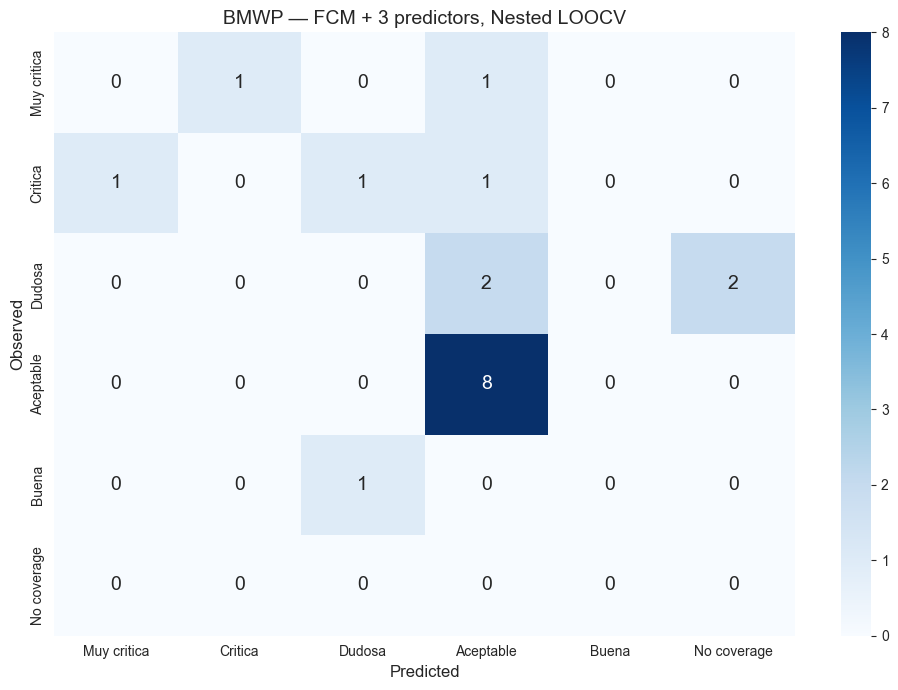

=== BMWP ===
              precision    recall  f1-score   support

 Muy critica       0.00      0.00      0.00         2
     Critica       0.00      0.00      0.00         3
      Dudosa       0.00      0.00      0.00         4
   Aceptable       0.67      1.00      0.80         8
       Buena       0.00      0.00      0.00         1
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.44        18
   macro avg       0.11      0.17      0.13        18
weighted avg       0.30      0.44      0.36        18

Cohen's Kappa: 0.163 | Coverage failures: 2 of 18



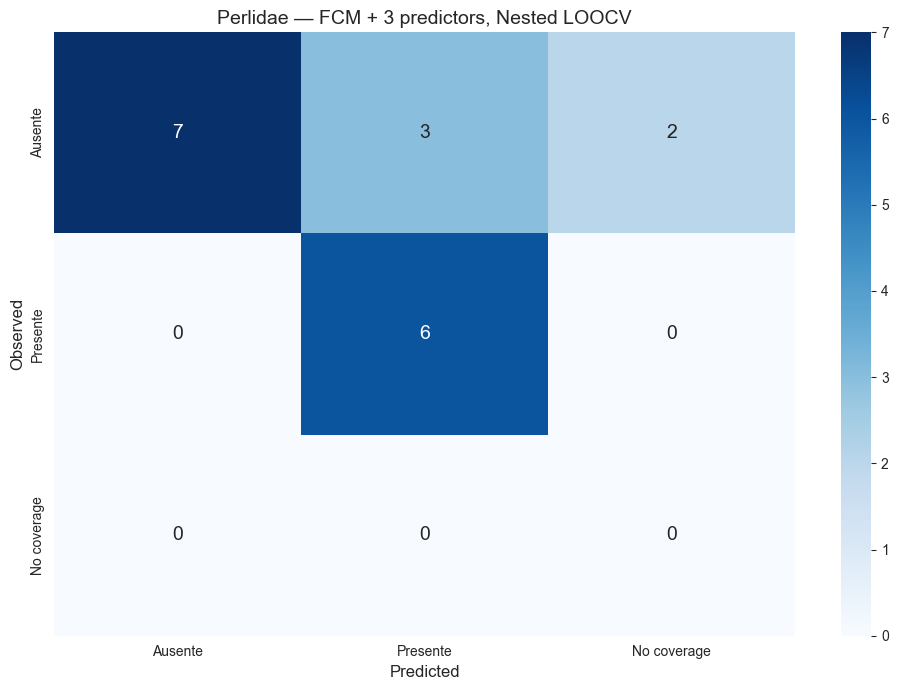

=== Perlidae ===
              precision    recall  f1-score   support

     Ausente       1.00      0.58      0.74        12
    Presente       0.67      1.00      0.80         6
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.72        18
   macro avg       0.56      0.53      0.51        18
weighted avg       0.89      0.72      0.76        18

Cohen's Kappa: 0.516 | Coverage failures: 2 of 18



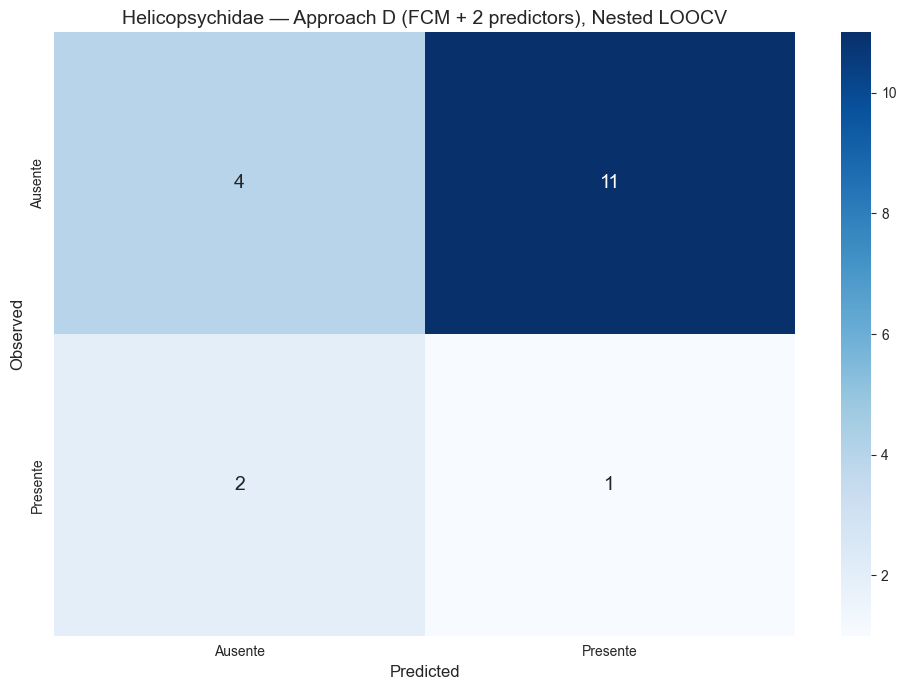

=== Helicopsychidae ===
              precision    recall  f1-score   support

     Ausente       0.67      0.27      0.38        15
    Presente       0.08      0.33      0.13         3

    accuracy                           0.28        18
   macro avg       0.38      0.30      0.26        18
weighted avg       0.57      0.28      0.34        18

Cohen's Kappa: -0.182 | Coverage failures: 0 of 18


In [10]:
# Per-target nested-LOOCV classification metrics, confusion matrices and reports
nest_class = {}
for name, cfg in nested_cfg.items():
    res = nested_results[name]
    classes = ([cl for cl in BMWP_ORDER if cl in res['y_true']] if cfg['is_bmwp']
               else ['Ausente', 'Presente'])
    nest_class[name] = compute_metrics(res['y_true'], res['y_pred'], classes)

# BMWP
res = nested_results['BMWP']
bmwp_classes = [cl for cl in BMWP_ORDER if cl in res['y_true']]
bmwp_labels = bmwp_classes + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], bmwp_labels,
               'BMWP — FCM + 3 predictors, Nested LOOCV',
               'fuzzy_bmwp_confusion_matrix_validation.png')
print("=== BMWP ===")
print(classification_report(res['y_true'], res['y_pred'], labels=bmwp_labels, zero_division=0))
print(f"Cohen's Kappa: {nest_class['BMWP']['kappa']:.3f} | Coverage failures: {len(res['failed'])} of 18\n")

# Perlidae
res = nested_results['Perlidae']
perl_labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], perl_labels,
               'Perlidae — FCM + 3 predictors, Nested LOOCV',
               'fuzzy_perlidae_confusion_matrix_validation.png')
print("=== Perlidae ===")
print(classification_report(res['y_true'], res['y_pred'], labels=perl_labels, zero_division=0))
print(f"Cohen's Kappa: {nest_class['Perlidae']['kappa']:.3f} | Coverage failures: {len(res['failed'])} of 18\n")

# Helicopsychidae (Approach D: FCM + 2 predictors)
res = nested_results['Helicopsychidae']
heli_labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], heli_labels,
               'Helicopsychidae — Approach D (FCM + 2 predictors), Nested LOOCV',
               'fuzzy_helicopsychidae_confusion_matrix_validation.png')
print("=== Helicopsychidae ===")
print(classification_report(res['y_true'], res['y_pred'], labels=heli_labels, zero_division=0))
print(f"Cohen's Kappa: {nest_class['Helicopsychidae']['kappa']:.3f} | Coverage failures: {len(res['failed'])} of 18")

In [11]:
# Predictor selection per fold (18 x n_pred matrix) — stability check
for name in nested_results:
    sel = nested_results[name]['sel']
    mat = pd.DataFrame(sel, index=[f"Fold {i + 1}" for i in range(len(sel))],
                       columns=[f"predictor_{j + 1}" for j in range(len(sel[0]))])
    modal = Counter(tuple(sorted(s)) for s in sel).most_common(1)[0]
    print(f"=== {name}: modal predictor set {modal[0]} selected in {modal[1]}/{len(sel)} folds ===")
    display(mat)

=== BMWP: modal predictor set ('Conductividad', 'SDT', 'Turbiedad') selected in 7/18 folds ===


,predictor_1,predictor_2,predictor_3
Fold 1,Turbiedad,Conductividad,SDT
Fold 2,Turbiedad,Conductividad,DBO5
Fold 3,Turbiedad,OD,DBO5
Fold 4,Turbiedad,Conductividad,SDT
Fold 5,Turbiedad,DBO5,Conductividad
Fold 6,Turbiedad,Conductividad,DBO5
Fold 7,Turbiedad,Conductividad,SDT
Fold 8,Turbiedad,Conductividad,SDT
Fold 9,Turbiedad,DBO5,Conductividad
Fold 10,Turbiedad,Conductividad,OD


=== Perlidae: modal predictor set ('DBO5', 'SDT', 'Turbiedad') selected in 12/18 folds ===


,predictor_1,predictor_2,predictor_3
Fold 1,Turbiedad,DBO5,SDT
Fold 2,Turbiedad,DBO5,SDT
Fold 3,Turbiedad,DBO5,Conductividad
Fold 4,Turbiedad,DBO5,SDT
Fold 5,Turbiedad,DBO5,Conductividad
Fold 6,Turbiedad,DBO5,Conductividad
Fold 7,Turbiedad,DBO5,SDT
Fold 8,Turbiedad,DBO5,SDT
Fold 9,Turbiedad,DBO5,Conductividad
Fold 10,Turbiedad,DBO5,SDT


=== Helicopsychidae: modal predictor set ('DBO5', 'SDT') selected in 11/18 folds ===


,predictor_1,predictor_2
Fold 1,SDT,DBO5
Fold 2,SDT,DBO5
Fold 3,OD,DBO5
Fold 4,SDT,OD
Fold 5,SDT,OD
Fold 6,SDT,OD
Fold 7,SDT,DBO5
Fold 8,SDT,DBO5
Fold 9,SDT,DBO5
Fold 10,Turbiedad,DBO5


In [12]:
# Export nested-LOOCV classification metrics and per-fold predictor stability
def r3(x):
    return round(float(x), 3)

def stability_str(sel):
    # Modal (most frequent) predictor set across folds and how many folds share it
    modal = Counter(tuple(sorted(s)) for s in sel).most_common(1)[0]
    return modal[0], f"{modal[1]}/{len(sel)}"

# Canonical per-target metric summary (shared schema, nested LOOCV)
summary = pd.DataFrame([
    {'target': name, 'technique': 'Fuzzy logic (redesigned)', 'validation': 'Nested LOOCV', 'n': 18,
     'precision': r3(nest_class[name]['precision']), 'recall': r3(nest_class[name]['recall']),
     'f1': r3(nest_class[name]['f1']), 'accuracy': r3(nest_class[name]['accuracy']),
     'kappa': r3(nest_class[name]['kappa'])}
    for name in nested_cfg
])
summary.to_csv("../../outputs/metrics_fuzzy_redesigned.csv", index=False)

# Nested-specific export with coverage failures and predictor-selection stability
nest_rows = []
for name in nested_cfg:
    m = nest_class[name]
    modal_set, stab = stability_str(nested_results[name]['sel'])
    nest_rows.append({'target': name, 'technique': 'Fuzzy logic (redesigned)',
                      'validation': 'Nested LOOCV', 'n': 18,
                      'precision': r3(m['precision']), 'recall': r3(m['recall']), 'f1': r3(m['f1']),
                      'accuracy': r3(m['accuracy']), 'kappa': r3(m['kappa']),
                      'failed_folds': len(nested_results[name]['failed']),
                      'modal_predictors': '+'.join(modal_set), 'predictor_stability': stab})
nested_metrics_df = pd.DataFrame(nest_rows)
nested_metrics_df.to_csv("../../outputs/metrics_fuzzy_nested_loocv.csv", index=False)
print("Saved outputs/metrics_fuzzy_redesigned.csv and outputs/metrics_fuzzy_nested_loocv.csv")
display(nested_metrics_df)

Saved outputs/metrics_fuzzy_redesigned.csv and outputs/metrics_fuzzy_nested_loocv.csv


,target,technique,validation,n,precision,recall,f1,accuracy,kappa,failed_folds,modal_predictors,predictor_stability
0,BMWP,Fuzzy logic (redesigned),Nested LOOCV,18,0.133,0.200,0.160,0.444,0.163,2,Conductividad+SDT+Turbiedad,7/18
1,Perlidae,Fuzzy logic (redesigned),Nested LOOCV,18,0.833,0.792,0.768,0.722,0.516,2,DBO5+SDT+Turbiedad,12/18
2,Helicopsychidae,Fuzzy logic (redesigned),Nested LOOCV,18,0.375,0.300,0.257,0.278,-0.182,0,DBO5+SDT,11/18


## 7. Numerical Performance (BMWP only)

Numerical accuracy of the crisp (defuzzified) BMWP predictions against the observed
BMWP/Col index under nested LOOCV, computed over the successful folds only (coverage
failures produce no crisp output and are excluded). MAE and RMSE are on the 0–120
BMWP/Col scale.

In [13]:
# BMWP numerical metrics on the crisp defuzzified output (successful folds only)
res = nested_results['BMWP']
y_obs = np.array(res['num_ok'])
y_hat = np.array(res['crisp_ok'])
n_ok = len(y_hat)

mae = mean_absolute_error(y_obs, y_hat)
rmse = float(np.sqrt(np.mean((y_obs - y_hat) ** 2)))
r2 = r2_score(y_obs, y_hat)
rs, p = spearmanr(y_obs, y_hat)

print(f"=== BMWP Numerical Performance (Nested LOOCV, n={n_ok} successful folds) ===")
print(f"MAE:  {mae:.2f} BMWP points")
print(f"RMSE: {rmse:.2f} BMWP points")
print(f"R²:   {r2:.3f}")
print(f"Spearman rs: {rs:.3f} (p = {p:.4f})")
print(f"Interpretation: on average, the model's BMWP predictions deviate")
print(f"by {mae:.2f} points from the observed values on the BMWP/Col scale (0-120).")

=== BMWP Numerical Performance (Nested LOOCV, n=16 successful folds) ===
MAE:  26.77 BMWP points
RMSE: 31.64 BMWP points
R²:   0.070
Spearman rs: 0.281 (p = 0.2916)
Interpretation: on average, the model's BMWP predictions deviate
by 26.77 points from the observed values on the BMWP/Col scale (0-120).


In [14]:
# Persist per-fold predictions and numerical metrics for the master table
station_col = 'Estación' if 'Estación' in bmwp_df.columns else bmwp_df.columns[0]
bmwp_loocv_pred = pd.DataFrame({
    'Station': [bmwp_df.iloc[i][station_col] for i in res['succ_idx']],
    'Observed_BMWP': res['num_ok'],
    'Predicted_BMWP': res['crisp_ok'],
})
bmwp_loocv_pred.to_csv("../../outputs/fuzzy_final_bmwp_loocv_predictions.csv", index=False)

num_row = {'model': 'Fuzzy redesigned', 'validation': 'Nested LOOCV', 'n': n_ok,
           'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 3),
           'rs': round(rs, 3), 'p_value': round(p, 4)}
pd.DataFrame([num_row]).to_csv("../../outputs/numerical_bmwp_fuzzy.csv", index=False)
pd.DataFrame([num_row]).to_csv("../../outputs/numerical_bmwp_fuzzy_nested.csv", index=False)

pd.DataFrame([
    {'system': 'Fuzzy logic (original)', 'evaluation': 'In-sample', 'n': 14, 'rs': 0.827, 'p_value': 0.000265},
    {'system': 'Fuzzy logic (redesigned)', 'evaluation': 'Nested LOOCV', 'n': n_ok, 'rs': round(rs, 3), 'p_value': p},
]).to_csv("../../outputs/spearman_comparison.csv", index=False)
print("Saved BMWP predictions, numerical metrics and Spearman comparison CSVs")

Saved BMWP predictions, numerical metrics and Spearman comparison CSVs


## 8. Visualisation

Two visual diagnostics are produced and saved to `outputs/`:

1. **Membership-function curves** for each predictor of each model (Low/Medium/High
   sets), derived from a Fuzzy C-Means fit on the **full dataset for illustration
   only** — the nested LOOCV models refit FCM per fold.
2. **Observed vs predicted BMWP** scatter (nested LOOCV crisp output) with a 1:1
   reference line, BMWP/Col quality-band backgrounds and station labels.

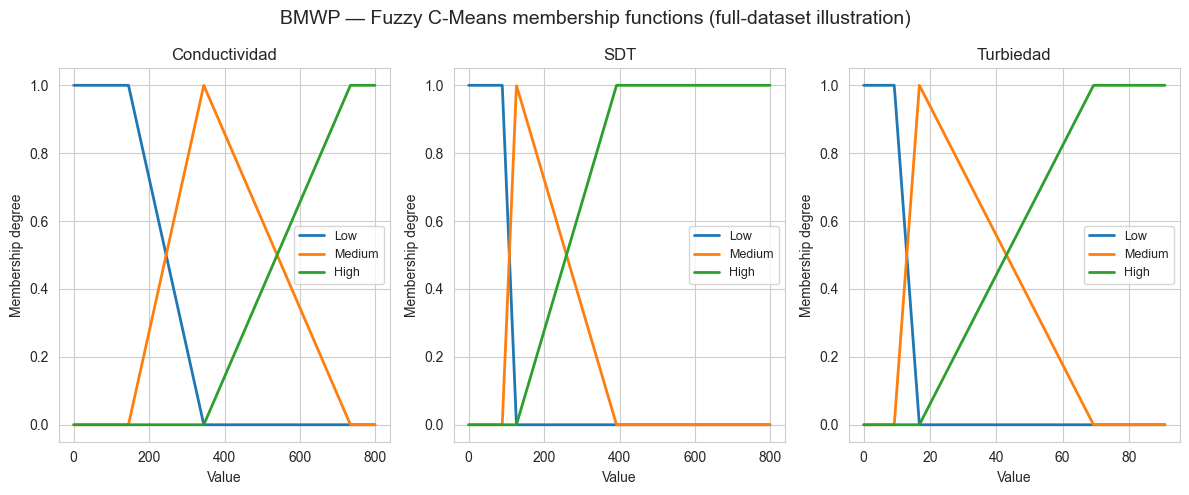

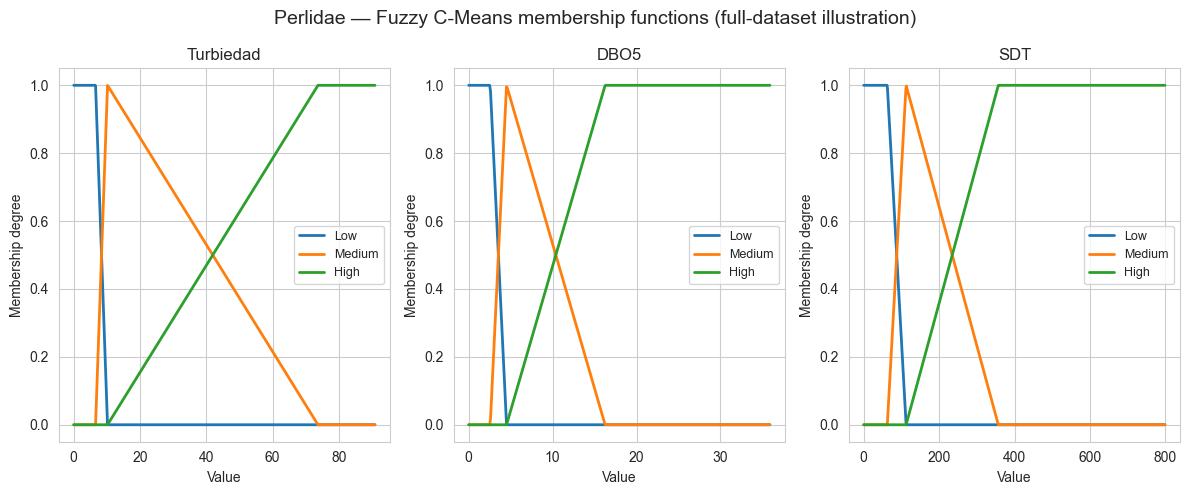

In [15]:
# Helper: plot Low/Medium/High membership functions, one subplot per predictor
def plot_membership(term_dict, predictors, title, filename):
    n = len(predictors)
    fig, axes = plt.subplots(1, n, figsize=(12, 5))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, predictors):
        u = np.arange(*UNIV[p])
        for lab, arr in term_dict[p].items():
            ax.plot(u, arr, linewidth=2, label=lab)
        ax.set_title(p)
        ax.set_xlabel('Value')
        ax.set_ylabel('Membership degree')
        ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

# BMWP and Perlidae: illustrative full-dataset FCM membership functions
plot_membership(fcm_terms(bmwp_df, bmwp_pred), bmwp_pred,
                'BMWP — Fuzzy C-Means membership functions (full-dataset illustration)',
                'fuzzy_membership_functions_bmwp.png')
plot_membership(fcm_terms(macro_df, perlidae_pred), perlidae_pred,
                'Perlidae — Fuzzy C-Means membership functions (full-dataset illustration)',
                'fuzzy_membership_functions_perlidae.png')

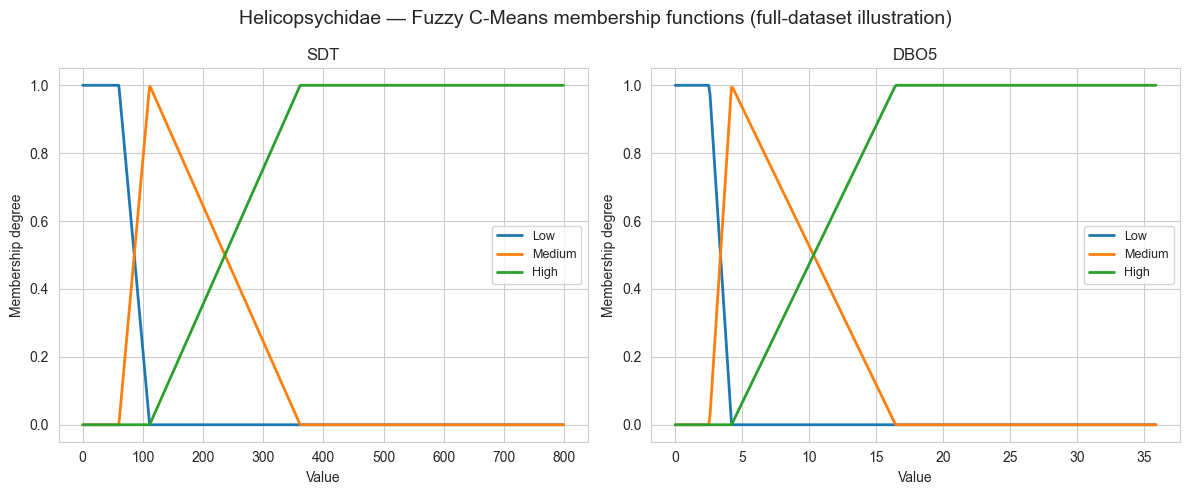

In [16]:
# Helicopsychidae: Fuzzy C-Means membership functions (full-dataset illustration)
plot_membership(fcm_terms(macro_df, helico_pred), helico_pred,
                'Helicopsychidae — Fuzzy C-Means membership functions (full-dataset illustration)',
                'fuzzy_membership_functions_helicopsychidae.png')

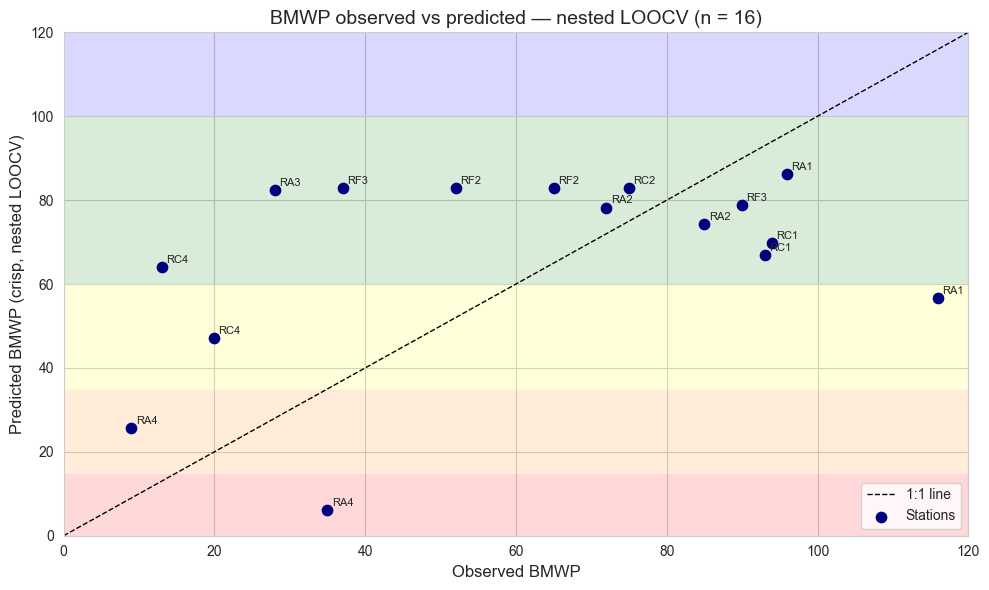

In [17]:
# Observed vs predicted BMWP scatter (nested LOOCV) with 1:1 line and quality-band backgrounds
res = nested_results['BMWP']
obs = np.array(res['num_ok'])
pred = np.array(res['crisp_ok'])
stations = [bmwp_df.iloc[i][station_col] for i in res['succ_idx']]
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]

plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(obs, pred, color='navy', s=55, zorder=3, label='Stations')
for x, y, lab in zip(obs, pred, stations):
    plt.annotate(str(lab), (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12)
plt.ylabel('Predicted BMWP (crisp, nested LOOCV)', fontsize=12)
plt.title(f'BMWP observed vs predicted — nested LOOCV (n = {len(obs)})', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../../outputs/fuzzy_bmwp_observed_vs_predicted_loocv.png", dpi=300)
plt.show()

## 9. Limitations

- **Predictor-selection leakage.** Predictor ranking by AIC was performed on the full
  dataset prior to cross-validation. This constitutes a mild form of selection
  leakage: the held-out observation in each fold may have marginally influenced which
  predictors were ranked highest. However, all membership function parameters and
  inference rules were estimated exclusively from the n−1 training observations of
  each fold, so the primary source of data leakage in the original system (rule
  generation from the full sample) is fully eliminated. The nested evaluation
  (Section 6) further re-ranks predictors inside each fold.
- **Membership functions for Helicopsychidae.** Helicopsychidae uses data-driven
  Fuzzy C-Means membership functions with two predictors (Approach D), not fixed
  expert membership functions. Approach D was selected because, in the leakage-free
  approach comparison, it was the only configuration to combine full rule coverage
  (zero coverage failures) with a positive Cohen's κ for this rare taxon (3 presences
  in 18 stations): a two-predictor antecedent yields a 3² = 9-cell rule grid that
  gives every held-out station a firing rule, whereas larger antecedent spaces leave
  presence cells empty and collapse to majority-class prediction. Under the stricter
  nested protocol reported above — where the two predictors are re-selected per fold
  by training-set Spearman correlation — coverage stays complete (0 failures) but κ
  falls slightly below zero, underscoring that no method achieves reliable
  discrimination for a 3/18 presence signal.
- **Spatial non-independence.** Stations lie along a single river; upstream/downstream
  samples share water masses, violating the independence LOOCV assumes. Blocked or
  spatial cross-validation would be stricter but is infeasible at n = 18.
- **Small sample.** With 18 observations (Helicopsychidae: 3 presences; BMWP 'Buena':
  1 station) every metric has wide uncertainty and a single fold can move a score.
- **Coverage failures.** A 'No coverage' fold means the held-out station's predictor
  combination matched no training rule — ecologically, a site whose conditions are
  unlike anything in the training set. They are counted as incorrect; the reduced
  antecedent sets keep them rare (0–2 of 18 folds).

## 10. Model Export for the Interface

The Perlidae fuzzy inference system (FCM membership functions + 3 predictors,
Approach E) is rebuilt on all 18 stations and its `ControlSystem` serialised to
`models/fuzzy_perlidae.pkl`, alongside `models/fuzzy_perlidae_meta.json` (predictors,
ranges, units, defuzzification threshold and validation metrics). The Flask interface
loads the control system, constructs a fresh `ControlSystemSimulation` per request,
and auto-reloads whenever this notebook is re-executed and the `.pkl` changes.

In [18]:
# ── Export final deployable Perlidae fuzzy model for the Interface ───────────
# Build the Mamdani control system on ALL 18 stations using the design-time
# predictor set, then serialise the ControlSystem + metadata to ../../models/.
# The interface rebuilds a fresh ControlSystemSimulation per request (skfuzzy
# simulations accumulate state, so a control system is the portable artefact).
import os, json, joblib

preds = perlidae_pred                       # ['Turbiedad', 'DBO5', 'SDT']
train = macro_df
terms = fcm_terms(train, preds)

antecedents = {}
for p in preds:
    a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
    for lab, arr in terms[p].items():
        a[lab] = arr
    antecedents[p] = a

cons_spec = bin_cons('Perlidae')
cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
for lab, kind, par in cons_spec['terms']:
    cons[lab] = getattr(fuzz, kind)(cons.universe, par)

rules = []
for _, row in train.iterrows():
    ante = functools.reduce(operator.and_,
                            [antecedents[p][cat_label(row[p], antecedents[p])] for p in preds])
    ct = cons['Presente'] if row['Perlidae'] == 1 else cons['Ausente']
    rules.append(ctrl.Rule(ante, ct))

perlidae_system = ctrl.ControlSystem(rules)

# Sanity check: rebuild a fresh simulation and predict station 0
_sim = ctrl.ControlSystemSimulation(perlidae_system)
for p in preds:
    _sim.input[p] = float(macro_df.iloc[0][p])
_sim.compute()
print('Sanity prediction (station 0): crisp =', round(_sim.output['Perlidae'], 3))

models_dir = os.path.join('..', '..', 'models')
os.makedirs(models_dir, exist_ok=True)
joblib.dump(perlidae_system, os.path.join(models_dir, 'fuzzy_perlidae.pkl'))

UNITS = {'Turbiedad': 'NTU', 'DBO5': 'mg/L', 'SDT': 'mg/L'}
meta = {
    'model_type': 'FuzzyMamdani', 'target': 'Perlidae',
    'display_name': 'Lógica difusa (Enfoque E) — Perlidae',
    'predictors': preds,
    'consequent_name': cons_spec['name'],
    'threshold': 0.5,
    'units': {p: UNITS.get(p, '') for p in preds},
    'ranges': {p: [round(float(macro_df[p].min()), 2), round(float(macro_df[p].max()), 2)]
               for p in preds},
    'metrics': {'kappa': round(float(nest_class['Perlidae']['kappa']), 3),
                'accuracy': round(float(nest_class['Perlidae']['accuracy']), 3),
                'f1': round(float(nest_class['Perlidae']['f1']), 3)},
    'output': ['class'],
    'classes': {'0': 'Ausencia', '1': 'Presencia'},
}
with open(os.path.join(models_dir, 'fuzzy_perlidae_meta.json'), 'w', encoding='utf-8') as fh:
    json.dump(meta, fh, indent=2, ensure_ascii=False)

print('✓ Exported models/fuzzy_perlidae.pkl | predictors:', preds)

Sanity prediction (station 0): crisp = 0.5
✓ Exported models/fuzzy_perlidae.pkl | predictors: ['Turbiedad', 'DBO5', 'SDT']
